<a href="https://colab.research.google.com/github/diegomartinmendez/nyse_nasdaq_forecasting/blob/main/estrategia_portafolio_precios_reales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estrategia de Portafolio vs SPY — Retornos con precios reales
**Mg. Ing. Diego Martín Méndez**

Esta versión calcula el retorno de cada acción usando precios reales descargados con yfinance.
El período de cada acción va desde `date_fundamentals + 1 día` hasta la fecha del próximo balance,
que es exactamente el período que midió el `target_return` original.

**Supuestos:** compra al precio de cierre del día posterior a la publicación del balance, sin costos de transacción ni slippage (supuesto estándar en investigación académica).

## 1. Instalaciones

In [ ]:
!pip install yfinance --quiet

## 2. Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import yfinance as yf
import time
import warnings
warnings.filterwarnings('ignore')
from pathlib import Path

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.grid':         True,
    'grid.alpha':        0.3,
    'font.family':       'sans-serif',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

## 3. Carga de datos

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_PATH = Path("/content/drive/MyDrive/Tesis/red_neuronal_final/pruebas_modelos_nuevos/archivos_mejor_modelo")

df = pd.read_parquet(BASE_PATH / 'predicciones_test_2024_2025.parquet')
df['date_fundamentals'] = pd.to_datetime(df['date_fundamentals'])

print('Shape:', df.shape)
print('Años disponibles:', sorted(df['date_fundamentals'].dt.year.unique()))
print('Columnas:', df.columns.tolist())
df.head()

Mounted at /content/drive
Shape: (351882, 14)
Años disponibles: [np.int32(2024), np.int32(2025)]
Columnas: ['symbol', 'date_fundamentals', 'target_return', 'target_return_pred', 'target_return_pred_raw', 'target_return_baseline', 'error_modelo', 'error_baseline', 'abs_error_modelo', 'abs_error_baseline', 'quintil_pred', 'year', 'month', 'sector']


,symbol,date_fundamentals,target_return,target_return_pred,target_return_pred_raw,target_return_baseline,error_modelo,error_baseline,abs_error_modelo,abs_error_baseline,quintil_pred,year,month,sector
0,BFI,2024-01-01,-0.197519,0.000625,0.000625,0.033017,-0.198144,-0.230536,0.198144,0.230536,2,2024,1,Consumer Cyclical
1,BFIIW,2024-01-01,0.143911,0.000625,0.000625,0.033017,0.143286,0.110894,0.143286,0.110894,2,2024,1,Consumer Cyclical
2,TTMI,2024-01-01,0.191734,0.006586,0.006586,0.033017,0.185148,0.158717,0.185148,0.158717,3,2024,1,Technology
3,BJRI,2024-01-02,0.004932,0.007852,0.007852,0.033017,-0.002920,-0.028085,0.002920,0.028085,4,2024,1,Consumer Cyclical
4,JACK,2024-01-21,-0.240619,0.007809,0.007809,0.033017,-0.248428,-0.273637,0.248428,0.273637,4,2024,1,Consumer Cyclical


## 4. Parámetros de la estrategia

In [ ]:
N_ACCIONES   = 50    # acciones seleccionadas por trimestre
CAPITAL_INIT = 100   # base 100 para el índice de retorno acumulado
SLEEP_SEG    = 0.3   # segundos entre descargas para no saturar yfinance

## 5. Calcular fecha del próximo balance por acción

Para cada acción, la fecha de fin del período es la fecha del **próximo balance** de esa misma empresa. Así el período de retorno es exactamente el que midió el `target_return` original.

In [ ]:
# Ordenar por symbol y fecha para calcular el próximo balance
df = df.sort_values(['symbol', 'date_fundamentals']).reset_index(drop=True)

# Próximo balance = siguiente date_fundamentals del mismo symbol
df['fecha_proximo_balance'] = (
    df.groupby('symbol')['date_fundamentals']
    .shift(-1)
)

# Fecha de compra = date_fundamentals + 1 día hábil
df['fecha_compra'] = df['date_fundamentals'] + pd.tseries.offsets.BDay(1)

# Fecha de venta = próximo balance - 1 día hábil
df['fecha_venta'] = df['fecha_proximo_balance'] - pd.tseries.offsets.BDay(1)

# Eliminar filas sin próximo balance (último período de cada empresa)
df_con_periodo = df.dropna(subset=['fecha_proximo_balance']).copy()

print('Filas con período completo:', len(df_con_periodo))
print('Filas sin próximo balance (descartadas):', len(df) - len(df_con_periodo))
df_con_periodo[['symbol', 'date_fundamentals', 'fecha_compra', 'fecha_venta']].head(10)

Filas con período completo: 345060
Filas sin próximo balance (descartadas): 6822


,symbol,date_fundamentals,fecha_compra,fecha_venta
0,A,2024-01-31,2024-02-01,2024-04-29
1,A,2024-04-30,2024-05-01,2024-07-30
2,A,2024-07-31,2024-08-01,2024-10-30
3,A,2024-10-31,2024-11-01,2025-01-30
4,A,2025-01-31,2025-02-03,2025-04-29
5,A,2025-04-30,2025-05-01,2025-07-30
7,AA,2024-03-31,2024-04-01,2024-06-28
8,AA,2024-06-30,2024-07-01,2024-09-27
9,AA,2024-09-30,2024-10-01,2024-12-30
10,AA,2024-12-31,2025-01-01,2025-03-28


## 6. Función para calcular retorno real con precios de yfinance

Para cada acción descargamos el precio de cierre ajustado en el período exacto y calculamos el retorno real. Si la descarga falla o no hay datos suficientes, la acción se descarta del portafolio de ese trimestre.

In [ ]:
def get_retorno_real(symbol, fecha_compra, fecha_venta, sleep=SLEEP_SEG):
    """
    Descarga el precio de cierre ajustado de `symbol` entre fecha_compra
    y fecha_venta y calcula el retorno del período.

    Retorna float con el retorno, o None si no hay datos.
    """
    try:
        # Agregar buffer de días para asegurar que capturamos los precios
        inicio = pd.Timestamp(fecha_compra) - pd.Timedelta(days=3)
        fin    = pd.Timestamp(fecha_venta)  + pd.Timedelta(days=3)

        data = yf.download(
            symbol,
            start    = inicio.strftime('%Y-%m-%d'),
            end      = fin.strftime('%Y-%m-%d'),
            progress = False,
            auto_adjust = True,
        )

        time.sleep(sleep)

        if data.empty or len(data) < 2:
            return None

        # Precio de compra: primer día disponible >= fecha_compra
        data_compra = data[data.index >= pd.Timestamp(fecha_compra)]
        if data_compra.empty:
            return None
        precio_compra = float(data_compra['Close'].iloc[0])

        # Precio de venta: último día disponible <= fecha_venta
        data_venta = data[data.index <= pd.Timestamp(fecha_venta)]
        if data_venta.empty:
            return None
        precio_venta = float(data_venta['Close'].iloc[-1])

        if precio_compra <= 0:
            return None

        return (precio_venta - precio_compra) / precio_compra

    except Exception as e:
        return None


# Test rápido
r = get_retorno_real('AAPL', '2024-02-02', '2024-05-01')
print(f'Test AAPL: {r:.2%}' if r is not None else 'Test AAPL: sin datos')

Test AAPL: -8.79%


## 7. Asignar trimestre y seleccionar Top-50 por trimestre

In [ ]:
df_con_periodo['trimestre'] = df_con_periodo['date_fundamentals'].dt.to_period('Q')

trimestres = sorted(df_con_periodo['trimestre'].unique())
print(f'Trimestres disponibles ({len(trimestres)}):')
for t in trimestres:
    n = (df_con_periodo['trimestre'] == t).sum()
    print(f'  {t}: {n} acciones con período completo')

Trimestres disponibles (7):
  2024Q1: 50942 acciones con período completo
  2024Q2: 51044 acciones con período completo
  2024Q3: 50678 acciones con período completo
  2024Q4: 50627 acciones con período completo
  2025Q1: 50325 acciones con período completo
  2025Q2: 46465 acciones con período completo
  2025Q3: 44979 acciones con período completo


## 8. Descarga de precios reales y cálculo de retornos

⚠️ **Esta celda puede tardar varios minutos** dependiendo de la cantidad de trimestres y acciones. Se descargan precios de hasta 50 acciones por trimestre.

El progreso se muestra en tiempo real.

In [ ]:
resultados = []

for trimestre in trimestres:
    grupo = df_con_periodo[df_con_periodo['trimestre'] == trimestre].copy()

    # Seleccionar Top-50 por predicción del modelo
    top_n = grupo.nlargest(N_ACCIONES, 'target_return_pred').copy()

    print(f'\n=== {trimestre} — {len(top_n)} acciones seleccionadas ===')

    retornos_reales = []
    retornos_originales = []
    simbolos_ok = []
    simbolos_fail = []

    for _, fila in top_n.iterrows():
        symbol       = fila['symbol']
        fecha_compra = fila['fecha_compra']
        fecha_venta  = fila['fecha_venta']

        retorno = get_retorno_real(symbol, fecha_compra, fecha_venta)

        if retorno is not None:
            retornos_reales.append(retorno)
            retornos_originales.append(fila['target_return'])
            simbolos_ok.append(symbol)
            print(f'  {symbol:10s} compra={fecha_compra.date()} '
                  f'venta={fecha_venta.date()} '
                  f'retorno_real={retorno:.2%} '
                  f'target_original={fila["target_return"]:.2%}')
        else:
            simbolos_fail.append(symbol)
            print(f'  {symbol:10s} SIN DATOS — descartada')

    if retornos_reales:
        retorno_portafolio    = np.mean(retornos_reales)
        retorno_target_medio  = np.mean(retornos_originales)
    else:
        retorno_portafolio   = 0.0
        retorno_target_medio = 0.0

    retorno_universo = grupo['target_return'].mean()

    print(f'  Retorno portafolio (precios reales): {retorno_portafolio:.2%}')
    print(f'  Retorno target original (promedio):  {retorno_target_medio:.2%}')
    print(f'  Retorno universo completo:           {retorno_universo:.2%}')
    print(f'  Acciones ok: {len(simbolos_ok)} | Descartadas: {len(simbolos_fail)}')

    resultados.append({
        'trimestre':              str(trimestre),
        'fecha_inicio':           grupo['date_fundamentals'].min(),
        'fecha_fin':              grupo['date_fundamentals'].max(),
        'n_universo':             len(grupo),
        'n_acciones_ok':          len(simbolos_ok),
        'n_acciones_fail':        len(simbolos_fail),
        'retorno_portafolio':     retorno_portafolio,
        'retorno_target_medio':   retorno_target_medio,
        'retorno_universo':       retorno_universo,
        'simbolos_ok':            simbolos_ok,
        'simbolos_fail':          simbolos_fail,
    })

df_resultados = pd.DataFrame(resultados)
print('\nFinalizado.')


=== 2024Q1 — 50 acciones seleccionadas ===
  PRFX       compra=2024-04-01 venta=2024-06-28 retorno_real=-72.88% target_original=-62.13%
  BTT        compra=2024-02-01 venta=2024-07-30 retorno_real=-1.25% target_original=-0.10%
  PSBD       compra=2024-04-01 venta=2024-06-28 retorno_real=3.91% target_original=3.85%
  JFR        compra=2024-02-01 venta=2024-07-30 retorno_real=10.40% target_original=10.32%
  VMO        compra=2024-02-29 venta=2024-08-30 retorno_real=7.87% target_original=8.27%
  XFLT       compra=2024-04-01 venta=2024-09-27 retorno_real=3.13% target_original=3.15%


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: XFLT-PA"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['XFLT-PA']: YFTzMissingError('possibly delisted; no timezone found')


  XFLT-PA    SIN DATOS — descartada


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: BLE"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BLE']: YFTzMissingError('possibly delisted; no timezone found')


  BLE        SIN DATOS — descartada


...

  COCH       compra=2025-04-01 venta=2025-06-27 retorno_real=16.79% target_original=15.56%
  ECDA       SIN DATOS — descartada


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['TORO']: YFPricesMissingError('possibly delisted; no price data found  (1d 2025-03-29 -> 2025-03-31)')


  WF         compra=2025-04-01 venta=2025-06-27 retorno_real=46.43% target_original=43.12%
  TORO       SIN DATOS — descartada
  TORO       compra=2025-04-01 venta=2025-06-27 retorno_real=-11.02% target_original=54.35%
  OXSQ       compra=2025-04-01 venta=2025-06-27 retorno_real=-9.72% target_original=-2.37%
  OXSQG      compra=2025-04-01 venta=2025-06-27 retorno_real=3.54% target_original=5.19%
  AVAL       compra=2025-04-01 venta=2025-06-27 retorno_real=4.22% target_original=12.64%
  AFCG       compra=2025-04-01 venta=2025-06-27 retorno_real=-14.54% target_original=-14.00%
  ICMB       compra=2025-04-01 venta=2025-06-27 retorno_real=-6.75% target_original=-0.41%
  MUFG       compra=2025-04-01 venta=2025-06-27 retorno_real=4.44% target_original=2.99%
  SMFG       compra=2025-04-01 venta=2025-06-27 retorno_real=0.80% target_original=-0.60%
  DPZ        compra=2025-03-24 venta=2025-06-13 retorno_real=-2.60% target_original=-4.67%
  IPCXU      compra=2025-04-01 venta=2025-06-27 retorno_r

ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['BTTC']: YFPricesMissingError('possibly delisted; no price data found  (1d 2025-07-29 -> 2025-10-02) (Yahoo error = "Data doesn\'t exist for startDate = 1753761600, endDate = 1759377600")')


  LMNR       compra=2025-08-01 venta=2025-10-30 retorno_real=-4.67% target_original=5.56%
  BTTC       SIN DATOS — descartada
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target_original=1.23%
  ATLC       compra=2025-10-01 venta=2025-09-29 retorno_real=5.01% target

## 9. Retorno acumulado de la estrategia

In [ ]:
df_resultados['factor_portafolio'] = 1 + df_resultados['retorno_portafolio']
df_resultados['factor_universo']    = 1 + df_resultados['retorno_universo']

df_resultados['acumulado_portafolio'] = CAPITAL_INIT * df_resultados['factor_portafolio'].cumprod()
df_resultados['acumulado_universo']   = CAPITAL_INIT * df_resultados['factor_universo'].cumprod()

retorno_total_portafolio = df_resultados['acumulado_portafolio'].iloc[-1] / CAPITAL_INIT - 1
retorno_total_universo   = df_resultados['acumulado_universo'].iloc[-1]   / CAPITAL_INIT - 1

print(f'Retorno acumulado — Portafolio Top-{N_ACCIONES}: {retorno_total_portafolio:.2%}')
print(f'Retorno acumulado — Universo completo:           {retorno_total_universo:.2%}')

Retorno acumulado — Portafolio Top-50: 28.68%
Retorno acumulado — Universo completo:           5.84%


## 10. Descarga del SPY — mismo período exacto que el portafolio

El retorno del SPY se calcula para el mismo período que cubre la estrategia: desde la primera fecha de compra hasta la última fecha de venta.

In [ ]:
fecha_compra_global = df_resultados['fecha_inicio'].min() + pd.tseries.offsets.BDay(1)
fecha_venta_global  = df_resultados['fecha_fin'].max()   - pd.tseries.offsets.BDay(1)

print(f'Período total del portafolio:')
print(f'  Compra:  {fecha_compra_global.date()}')
print(f'  Venta:   {fecha_venta_global.date()}')

spy_raw = yf.download(
    'SPY',
    start       = (fecha_compra_global - pd.Timedelta(days=3)).strftime('%Y-%m-%d'),
    end         = (fecha_venta_global  + pd.Timedelta(days=3)).strftime('%Y-%m-%d'),
    progress    = False,
    auto_adjust = True,
)

if not spy_raw.empty:
    spy_raw.index = pd.to_datetime(spy_raw.index)

    # Retorno acumulado del SPY trimestre a trimestre
    spy_trimestral = []
    for _, row in df_resultados.iterrows():
        f_ini = pd.Timestamp(row['fecha_inicio']) + pd.tseries.offsets.BDay(1)
        f_fin = pd.Timestamp(row['fecha_fin'])   - pd.tseries.offsets.BDay(1)

        spy_p = spy_raw[
            (spy_raw.index >= f_ini - pd.Timedelta(days=3)) &
            (spy_raw.index <= f_fin + pd.Timedelta(days=3))
        ]

        if len(spy_p) >= 2:
            r_spy = float(
                (spy_p['Close'].iloc[-1] - spy_p['Close'].iloc[0])
                / spy_p['Close'].iloc[0]
            )
        else:
            r_spy = 0.0
        spy_trimestral.append(r_spy)

    df_resultados['retorno_spy']   = spy_trimestral
    df_resultados['factor_spy']    = 1 + df_resultados['retorno_spy']
    df_resultados['acumulado_spy'] = CAPITAL_INIT * df_resultados['factor_spy'].cumprod()

    retorno_total_spy = df_resultados['acumulado_spy'].iloc[-1] / CAPITAL_INIT - 1
    print(f'\nRetorno acumulado — SPY: {retorno_total_spy:.2%}')
else:
    print('No se pudo descargar SPY.')

Período total del portafolio:
  Compra:  2024-01-02
  Venta:   2025-09-29

Retorno acumulado — SPY: 42.06%


## 11. Tabla comparativa por trimestre

In [ ]:
has_spy = 'retorno_spy' in df_resultados.columns

cols = ['trimestre', 'n_acciones_ok', 'retorno_portafolio',
        'retorno_target_medio', 'retorno_universo']
if has_spy:
    cols.append('retorno_spy')

df_tabla = df_resultados[cols].copy()
for col in cols[2:]:
    df_tabla[col] = df_tabla[col].map(lambda x: f'{x:.2%}')

df_tabla

,trimestre,n_acciones_ok,retorno_portafolio,retorno_target_medio,retorno_universo,retorno_spy
0,2024Q1,39,-1.28%,-1.02%,0.41%,10.82%
1,2024Q2,48,13.03%,14.07%,1.63%,4.78%
2,2024Q3,45,-0.19%,-0.13%,0.45%,5.53%
3,2024Q4,48,-4.17%,-1.90%,0.04%,2.24%
4,2025Q1,47,7.57%,14.55%,1.90%,-5.22%
5,2025Q2,50,11.18%,12.52%,0.74%,10.78%
6,2025Q3,49,0.81%,-9.47%,0.54%,7.99%


## 12. Gráfico 1 — Retorno acumulado

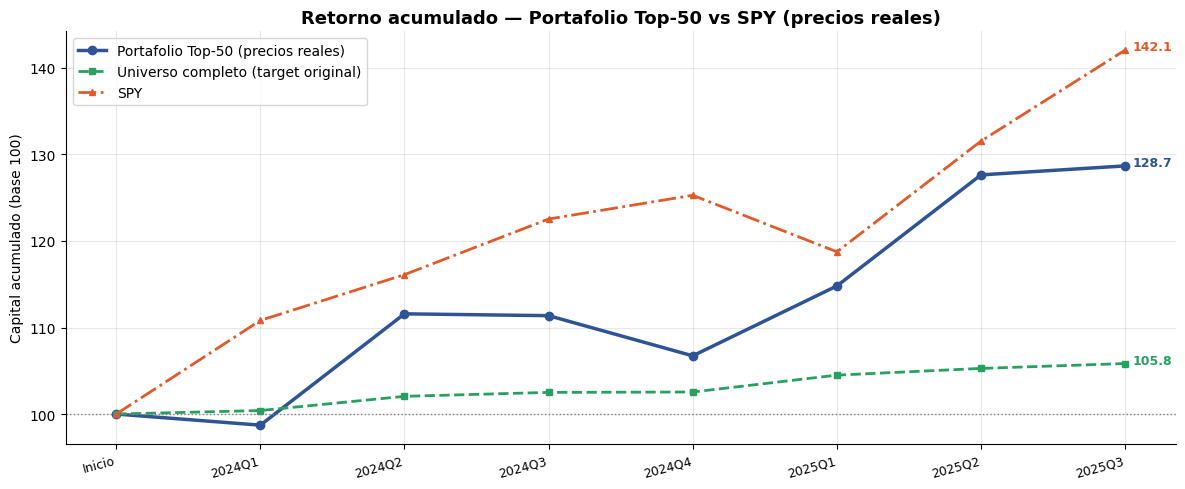

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

labels_ext       = ['Inicio'] + df_resultados['trimestre'].tolist()
x_ext            = range(len(labels_ext))
y_portafolio     = [CAPITAL_INIT] + df_resultados['acumulado_portafolio'].tolist()
y_universo       = [CAPITAL_INIT] + df_resultados['acumulado_universo'].tolist()

ax.plot(x_ext, y_portafolio, marker='o', linewidth=2.5, color='#2E5496',
        label=f'Portafolio Top-{N_ACCIONES} (precios reales)', markersize=6)
ax.plot(x_ext, y_universo,   marker='s', linewidth=2,   color='#27A060',
        linestyle='--', label='Universo completo (target original)', markersize=5)

if has_spy:
    y_spy = [CAPITAL_INIT] + df_resultados['acumulado_spy'].tolist()
    ax.plot(x_ext, y_spy, marker='^', linewidth=2, color='#E05A2B',
            linestyle='-.', label='SPY', markersize=5)
    ax.annotate(f'{y_spy[-1]:.1f}', xy=(len(y_spy)-1, y_spy[-1]),
                xytext=(5,0), textcoords='offset points',
                color='#E05A2B', fontweight='bold', fontsize=9)

ax.axhline(CAPITAL_INIT, color='gray', linewidth=1, linestyle=':')
ax.set_xticks(list(x_ext))
ax.set_xticklabels(labels_ext, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Capital acumulado (base 100)')
ax.set_title(f'Retorno acumulado — Portafolio Top-{N_ACCIONES} vs SPY (precios reales)',
             fontweight='bold', fontsize=13)
ax.legend(loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.0f'))

for y_s, color in [(y_portafolio, '#2E5496'), (y_universo, '#27A060')]:
    ax.annotate(f'{y_s[-1]:.1f}', xy=(len(y_s)-1, y_s[-1]),
                xytext=(5, 0), textcoords='offset points',
                color=color, fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig(BASE_PATH / 'grafico_portafolio_real_acumulado.png', dpi=150)
plt.show()

## 13. Gráfico 2 — Retorno por trimestre (barras)

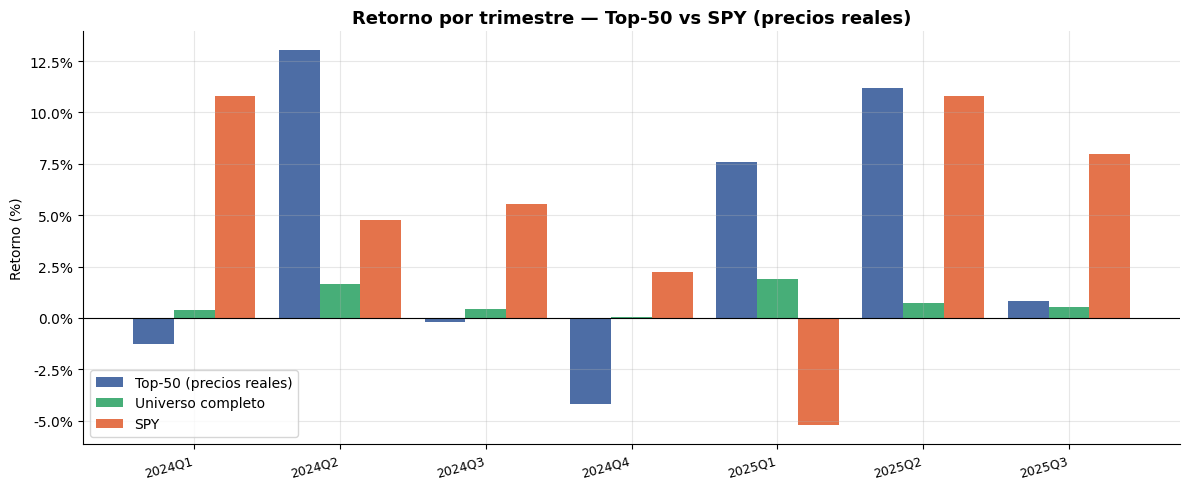

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

x     = np.arange(len(df_resultados))
width = 0.28

ax.bar(x - width, df_resultados['retorno_portafolio'] * 100,
       width, label=f'Top-{N_ACCIONES} (precios reales)', color='#2E5496', alpha=0.85)
ax.bar(x,         df_resultados['retorno_universo'] * 100,
       width, label='Universo completo', color='#27A060', alpha=0.85)

if has_spy:
    ax.bar(x + width, df_resultados['retorno_spy'] * 100,
           width, label='SPY', color='#E05A2B', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_resultados['trimestre'].tolist(), rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Retorno (%)')
ax.set_title(f'Retorno por trimestre — Top-{N_ACCIONES} vs SPY (precios reales)',
             fontweight='bold', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.savefig(BASE_PATH / 'grafico_portafolio_real_trimestral.png', dpi=150)
plt.show()

## 14. Gráfico 3 — Retorno real (yfinance) vs target original del modelo

Este gráfico muestra cuán bien el `target_return` original aproxima el retorno real calculado con precios de mercado.

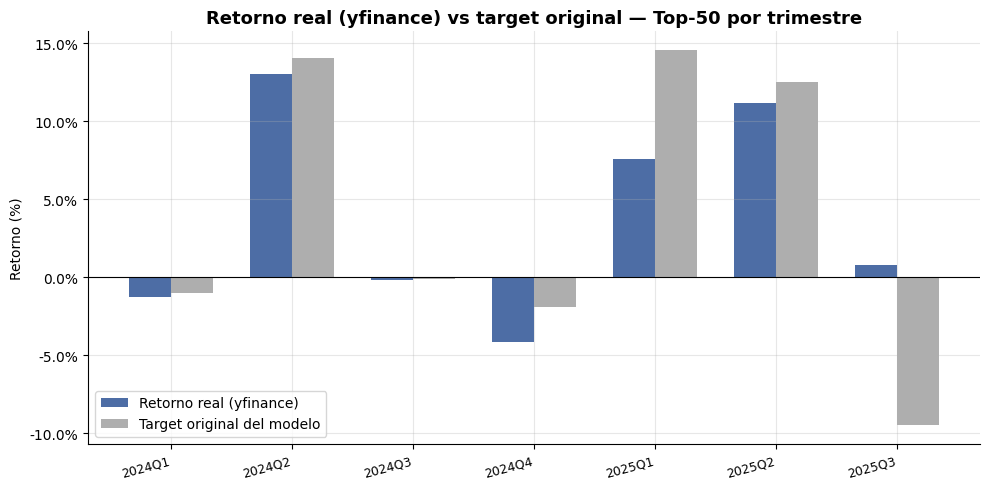

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

x     = np.arange(len(df_resultados))
width = 0.35

ax.bar(x - width/2, df_resultados['retorno_portafolio'] * 100,
       width, label='Retorno real (yfinance)', color='#2E5496', alpha=0.85)
ax.bar(x + width/2, df_resultados['retorno_target_medio'] * 100,
       width, label='Target original del modelo', color='#A0A0A0', alpha=0.85)

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(df_resultados['trimestre'].tolist(), rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Retorno (%)')
ax.set_title('Retorno real (yfinance) vs target original — Top-50 por trimestre',
             fontweight='bold', fontsize=13)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.tight_layout()
plt.savefig(BASE_PATH / 'grafico_portafolio_real_vs_target.png', dpi=150)
plt.show()

## 15. Tabla resumen final

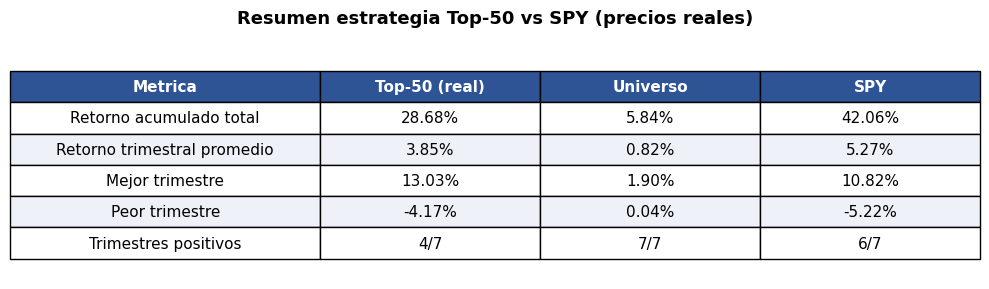

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

resumen_vals = [
    ['Metrica', f'Top-{N_ACCIONES} (real)', 'Universo'] + (['SPY'] if has_spy else []),
    ['Retorno acumulado total',
     f'{retorno_total_portafolio:.2%}',
     f'{retorno_total_universo:.2%}'] + ([f'{retorno_total_spy:.2%}'] if has_spy else []),
    ['Retorno trimestral promedio',
     f"{df_resultados['retorno_portafolio'].mean():.2%}",
     f"{df_resultados['retorno_universo'].mean():.2%}"] +
     ([f"{df_resultados['retorno_spy'].mean():.2%}"] if has_spy else []),
    ['Mejor trimestre',
     f"{df_resultados['retorno_portafolio'].max():.2%}",
     f"{df_resultados['retorno_universo'].max():.2%}"] +
     ([f"{df_resultados['retorno_spy'].max():.2%}"] if has_spy else []),
    ['Peor trimestre',
     f"{df_resultados['retorno_portafolio'].min():.2%}",
     f"{df_resultados['retorno_universo'].min():.2%}"] +
     ([f"{df_resultados['retorno_spy'].min():.2%}"] if has_spy else []),
    ['Trimestres positivos',
     f"{(df_resultados['retorno_portafolio'] > 0).sum()}/{len(df_resultados)}",
     f"{(df_resultados['retorno_universo'] > 0).sum()}/{len(df_resultados)}"] +
     ([f"{(df_resultados['retorno_spy'] > 0).sum()}/{len(df_resultados)}"] if has_spy else []),
]

n_cols     = len(resumen_vals[0])
col_widths = [0.32] + [0.68 / (n_cols - 1)] * (n_cols - 1)

table = ax.table(cellText=resumen_vals[1:], colLabels=resumen_vals[0],
                 cellLoc='center', loc='center', colWidths=col_widths)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.9)

for (row, col), cell in table.get_celld().items():
    if row == 0:
        cell.set_facecolor('#2E5496')
        cell.set_text_props(color='white', fontweight='bold')
    elif row % 2 == 0:
        cell.set_facecolor('#EEF2F8')

ax.set_title(f'Resumen estrategia Top-{N_ACCIONES} vs SPY (precios reales)',
             fontweight='bold', pad=20, fontsize=13)
plt.tight_layout()
plt.savefig(BASE_PATH / 'grafico_portafolio_real_resumen.png', dpi=150)
plt.show()

## 16. Guardar resultados y resumen final en consola

In [ ]:
df_export = df_resultados.drop(columns=['simbolos_ok', 'simbolos_fail'], errors='ignore')
df_export.to_parquet(BASE_PATH / 'resultados_portafolio_real.parquet', index=False)
df_export.to_csv(BASE_PATH / 'resultados_portafolio_real.csv', index=False)
print('Archivos guardados en Drive.')

print('\n' + '='*58)
print(f'  RESUMEN FINAL — Portafolio Top-{N_ACCIONES} con precios reales')
print('='*58)
print(f'  Retorno acumulado Portafolio : {retorno_total_portafolio:.2%}')
print(f'  Retorno acumulado Universo   : {retorno_total_universo:.2%}')
if has_spy:
    print(f'  Retorno acumulado SPY        : {retorno_total_spy:.2%}')
    alpha = retorno_total_portafolio - retorno_total_spy
    print(f'  Alpha vs SPY                 : {alpha:+.2%}')
print('='*58)

Archivos guardados en Drive.

  RESUMEN FINAL — Portafolio Top-50 con precios reales
  Retorno acumulado Portafolio : 28.68%
  Retorno acumulado Universo   : 5.84%
  Retorno acumulado SPY        : 42.06%
  Alpha vs SPY                 : -13.38%


In [ ]:
BASE_PATH = Path("/content/drive/MyDrive/Tesis/red_neuronal_final/pruebas_modelos_nuevos/archivos_mejor_modelo")

df = pd.read_parquet(BASE_PATH / 'predicciones_test_2024_2025.parquet')

df["date_fundamentals"] = pd.to_datetime(df["date_fundamentals"])
df["error_abs"] = df["error_modelo"].abs()
df["year"] = df["date_fundamentals"].dt.year

# 1. Estadísticas generales del error
print("=== Distribución del error absoluto ===")
print(df["error_abs"].describe(percentiles=[.25, .5, .75, .90, .95, .99]))

# 2. Errores por año
print("\n=== MAE por año ===")
print(df.groupby("year")["error_abs"].mean().round(4))

# 3. Peores 10 predicciones
print("\n=== Top 10 peores predicciones ===")
cols = ["symbol", "date_fundamentals", "target_return",
        "target_return_pred", "error_modelo", "error_abs"]
if "sector" in df.columns:
    cols.insert(2, "sector")
print(df.nlargest(10, "error_abs")[cols].to_string(index=False))

# 4. Error por sector (si existe)
if "sector" in df.columns:
    print("\n=== MAE por sector ===")
    print(df.groupby("sector")["error_abs"].agg(["mean","count"])
            .sort_values("mean", ascending=False).round(4).to_string())

# 5. Sesgo del modelo
print("\n=== Sesgo (error medio con signo) ===")
print(df.groupby("year")["error_modelo"].mean().round(4))

# 6. Errores por quintil de retorno real
df["quintil_real"] = pd.qcut(df["target_return"], q=5, labels=[1,2,3,4,5])
print("\n=== MAE por quintil de retorno REAL ===")
print(df.groupby("quintil_real", observed=False)["error_abs"].mean().round(4))

=== Distribución del error absoluto ===
count    3.518820e+05
mean     2.581406e-02
std      1.328317e-01
min      2.167792e-07
25%      2.164008e-03
50%      5.439916e-03
75%      8.039439e-03
90%      8.902376e-03
95%      1.231535e-01
99%      4.780773e-01
max      4.118048e+00
Name: error_abs, dtype: float64

=== MAE por año ===
year
2024    0.0282
2025    0.0226
Name: error_abs, dtype: float64

=== Top 10 peores predicciones ===
symbol date_fundamentals     sector  target_return  target_return_pred  error_modelo  error_abs
  IMAB        2024-12-31 Healthcare       4.102021           -0.016026      4.118048   4.118048
  IMAB        2024-12-31 Healthcare       4.102021           -0.016026      4.118048   4.118048
  IMAB        2025-03-31 Healthcare       4.102021           -0.016026      4.118047   4.118047
  IMAB        2025-03-31 Healthcare       4.102021           -0.016026      4.118047   4.118047
 PTIXW        2025-03-31 Healthcare       4.102021           -0.014692      4.1167